# Práctica de PyMongo

In [1]:
from pymongo import MongoClient

client = MongoClient("mongodb://localhost:27017", serverSelectionTimeoutMS=3000)
client.admin.command("ping")
print("✅ MongoDB está funcionando")


✅ MongoDB está funcionando


In [2]:
db = client["restaurantes_db"]
collection = db["restaurants"]

print("Número de documentos:")
print(collection.count_documents({}))


Número de documentos:
3776


# Visualización de documentos

In [3]:
from pprint import pprint

for doc in collection.find().limit(5):
    pprint(doc)
    print("-"*60)


{'_id': ObjectId('699341e10d4a09e14e8c723d'),
 'address': {'building': '1',
             'coord': [-73.96926909999999, 40.7685235],
             'street': 'East   66 Street',
             'zipcode': '10065'},
 'avg_score': 3.25,
 'borough': 'Manhattan',
 'cuisine': 'American ',
 'grades': [{'date': datetime.datetime(2014, 5, 7, 0, 0),
             'grade': 'A',
             'score': 3},
            {'date': datetime.datetime(2013, 5, 3, 0, 0),
             'grade': 'A',
             'score': 4},
            {'date': datetime.datetime(2012, 4, 30, 0, 0),
             'grade': 'A',
             'score': 6},
            {'date': datetime.datetime(2011, 12, 27, 0, 0),
             'grade': 'A',
             'score': 0}],
 'name': '1 East 66Th Street Kitchen',
 'restaurant_id': '40359480'}
------------------------------------------------------------
{'_id': ObjectId('699341e10d4a09e14e8c723e'),
 'address': {'building': '2206',
             'coord': [-74.1377286, 40.6119572],
             's

In [4]:
from pprint import pprint

for doc in collection.find(
    {},
    {"_id": 0, "name": 1, "borough": 1, "cuisine": 1}
).limit(10):
    pprint(doc)


{'borough': 'Manhattan',
 'cuisine': 'American ',
 'name': '1 East 66Th Street Kitchen'}
{'borough': 'Staten Island',
 'cuisine': 'Jewish/Kosher',
 'name': 'Kosher Island'}
{'borough': 'Bronx', 'cuisine': 'American ', 'name': 'Wild Asia'}
{'borough': 'Brooklyn',
 'cuisine': 'Ice Cream, Gelato, Yogurt, Ices',
 'name': 'Taste The Tropics Ice Cream'}
{'borough': 'Brooklyn', 'cuisine': 'Delicatessen', 'name': "Wilken'S Fine Food"}
{'borough': 'Brooklyn', 'cuisine': 'Delicatessen', 'name': 'Nordic Delicacies'}
{'borough': 'Queens',
 'cuisine': 'Ice Cream, Gelato, Yogurt, Ices',
 'name': 'Carvel Ice Cream'}
{'borough': 'Brooklyn',
 'cuisine': 'Ice Cream, Gelato, Yogurt, Ices',
 'name': 'Carvel Ice Cream'}
{'borough': 'Brooklyn', 'cuisine': 'Jewish/Kosher', 'name': 'Seuda Foods'}
{'borough': 'Brooklyn', 'cuisine': 'American ', 'name': 'The Movable Feast'}


# Consultas restaurantes Manhattan

In [5]:
for doc in collection.find(
    {"borough": "Manhattan"},
    {"_id": 0, "name": 1, "cuisine": 1}
).limit(10):
    print(doc)


{'cuisine': 'American ', 'name': '1 East 66Th Street Kitchen'}
{'cuisine': 'Delicatessen', 'name': "Bully'S Deli"}
{'cuisine': 'American ', 'name': 'Glorious Food'}
{'cuisine': 'American ', 'name': 'P & S Deli Grocery'}
{'cuisine': 'Chicken', 'name': "Harriet'S Kitchen"}
{'cuisine': 'Turkish', 'name': 'The Country Cafe'}
{'cuisine': 'American ', 'name': 'Angelika Film Center'}
{'cuisine': 'American ', 'name': 'Downtown Deli'}
{'cuisine': 'Irish', 'name': 'Dj Reynolds Pub And Restaurant'}
{'cuisine': 'Bakery', 'name': "Olive'S"}


# Consulta restaurantes tipo American Brooklyn

In [6]:
for doc in collection.find(
    {"borough": "Brooklyn", "cuisine": "American"},
    {"_id": 0, "name": 1, }
).limit(10):
    print(doc)


In [7]:
print(collection.count_documents(
    {"borough": "Brooklyn", "cuisine": "American"}
))


0


# Consulta restaurantes con score mayor que 10


In [8]:
for doc in collection.find(
    {"grades.score": {"$gt": 10}},
    {"_id": 0, "name": 1, "grades": 1}
).limit(5):
    print(doc)


{'grades': [{'date': datetime.datetime(2014, 10, 6, 0, 0), 'grade': 'A', 'score': 9}, {'date': datetime.datetime(2014, 5, 20, 0, 0), 'grade': 'A', 'score': 12}, {'date': datetime.datetime(2013, 4, 4, 0, 0), 'grade': 'A', 'score': 12}, {'date': datetime.datetime(2012, 1, 24, 0, 0), 'grade': 'A', 'score': 9}], 'name': 'Kosher Island'}
{'grades': [{'date': datetime.datetime(2014, 5, 28, 0, 0), 'grade': 'A', 'score': 11}, {'date': datetime.datetime(2013, 6, 19, 0, 0), 'grade': 'A', 'score': 4}, {'date': datetime.datetime(2012, 6, 15, 0, 0), 'grade': 'A', 'score': 3}], 'name': 'Wild Asia'}
{'grades': [{'date': datetime.datetime(2014, 7, 14, 0, 0), 'grade': 'A', 'score': 12}, {'date': datetime.datetime(2013, 7, 10, 0, 0), 'grade': 'A', 'score': 8}, {'date': datetime.datetime(2012, 7, 11, 0, 0), 'grade': 'A', 'score': 5}, {'date': datetime.datetime(2012, 2, 23, 0, 0), 'grade': 'A', 'score': 8}], 'name': 'Taste The Tropics Ice Cream'}
{'grades': [{'date': datetime.datetime(2014, 5, 29, 0, 0), 

# Distribución de restaurantes por borough

In [9]:
pipeline = [
    {
        "$group": {
            "_id": "$borough",
            "count": {"$sum": 1}
        }
    },
    {
        "$sort": {"count": -1}
    }
]

borough_data = list(collection.aggregate(pipeline))

borough_data


[{'_id': 'Manhattan', 'count': 1883},
 {'_id': 'Queens', 'count': 738},
 {'_id': 'Brooklyn', 'count': 684},
 {'_id': 'Bronx', 'count': 313},
 {'_id': 'Staten Island', 'count': 158}]

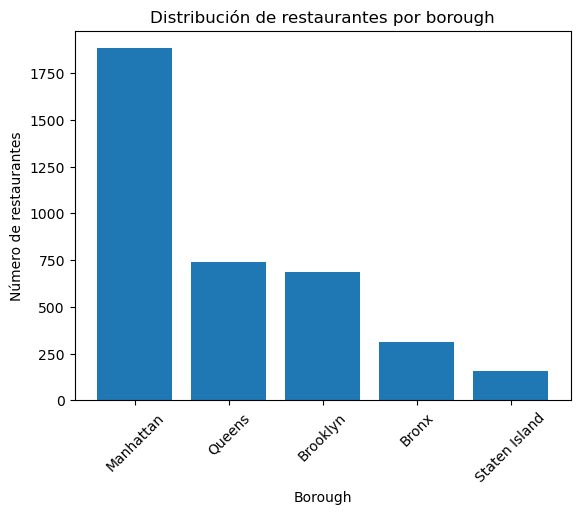

In [10]:
import matplotlib.pyplot as plt

boroughs = [doc["_id"] for doc in borough_data]
counts = [doc["count"] for doc in borough_data]

plt.figure()
plt.bar(boroughs, counts)
plt.xticks(rotation=45)
plt.title("Distribución de restaurantes por borough")
plt.xlabel("Borough")
plt.ylabel("Número de restaurantes")
plt.show()


# Inserción de nuevos restaurantes desde new_restaurants.json a partir del archivo JSON proporcionado.

In [11]:
import json

with open("new_restaurants.json", "r", encoding="utf-8") as file:
    new_data = json.load(file)

len(new_data)


4

In [12]:
result = collection.insert_many(new_data)
len(result.inserted_ids)


4

In [13]:
collection.count_documents({})


3780

# Vamos con avg_score. Si no existen puntuaciones, se asigna el valor None.

In [14]:
for doc in collection.find():
    grades = doc.get("grades", [])
    
    if grades:
        scores = [g["score"] for g in grades if "score" in g]
        avg_score = sum(scores) / len(scores)
    else:
        avg_score = None
    
    collection.update_one(
        {"_id": doc["_id"]},
        {"$set": {"avg_score": avg_score}}
    )


In [15]:
collection.find_one({}, {"name": 1, "avg_score": 1, "_id": 0})


{'name': '1 East 66Th Street Kitchen', 'avg_score': 3.25}

# Restaurantes con avg_score mayor que 10

In [16]:
for doc in collection.find(
    {"avg_score": {"$gt": 10}},
    {"name": 1, "avg_score": 1, "_id": 0}
).sort("avg_score", -1).limit(5):
    print(doc)


{'name': 'Bella Napoli', 'avg_score': 38.6}
{'name': 'West 79Th Street Boat Basin Cafe', 'avg_score': 36.0}
{'name': "Murals On 54/Randolphs'S", 'avg_score': 33.666666666666664}
{'name': 'Live Bait Bar & Restaurant', 'avg_score': 32.6}
{'name': 'Nanni Restaurant', 'avg_score': 32.142857142857146}


# Media de avg_score por borough

In [17]:
pipeline = [
    {
        "$group": {
            "_id": "$borough",
            "media_avg_score": {"$avg": "$avg_score"}
        }
    },
    {
        "$sort": {"media_avg_score": -1}
    }
]

borough_avg = list(collection.aggregate(pipeline))
borough_avg


[{'_id': 'Queens', 'media_avg_score': 11.38415440702026},
 {'_id': 'Brooklyn', 'media_avg_score': 11.265791214146477},
 {'_id': 'Manhattan', 'media_avg_score': 11.092759148268973},
 {'_id': 'Staten Island', 'media_avg_score': 11.000060277275468},
 {'_id': 'Bronx', 'media_avg_score': 10.942729457713686}]

# Visualización geográfica de restaurantes por tipo de cocina

In [18]:
import matplotlib.pyplot as plt

docs = collection.find(
    {"address.coord": {"$exists": True}},
    {"address.coord": 1, "cuisine": 1, "_id": 0}
)

data = list(docs)

len(data)


3780

In [19]:
lons = []
lats = []
cuisines = []

for doc in data:
    coord = doc["address"]["coord"]
    lons.append(coord[0])
    lats.append(coord[1])
    cuisines.append(doc.get("cuisine", "Unknown"))


# Visualización geográfica simple de restaurantes

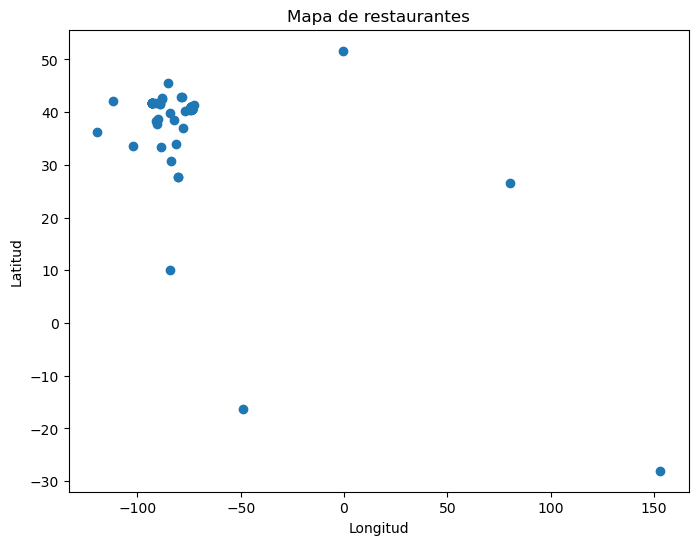

In [20]:
plt.figure(figsize=(8,6))
plt.scatter(lons, lats)

plt.title("Mapa de restaurantes")
plt.xlabel("Longitud")
plt.ylabel("Latitud")

plt.show()


# Mapa de restaurantes (filtrando coordenadas fuera de rango NYC)

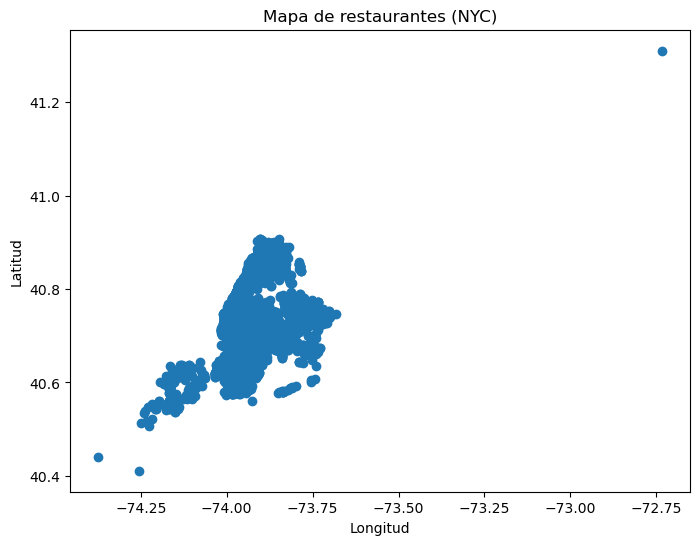

In [21]:
lons_f = []
lats_f = []

for lon, lat in zip(lons, lats):
    if -75 <= lon <= -70 and 40 <= lat <= 42:
        lons_f.append(lon)
        lats_f.append(lat)

plt.figure(figsize=(8,6))
plt.scatter(lons_f, lats_f)
plt.title("Mapa de restaurantes (NYC)")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.show()


# Mapa de restaurantes coloreado por tipo de cocina 

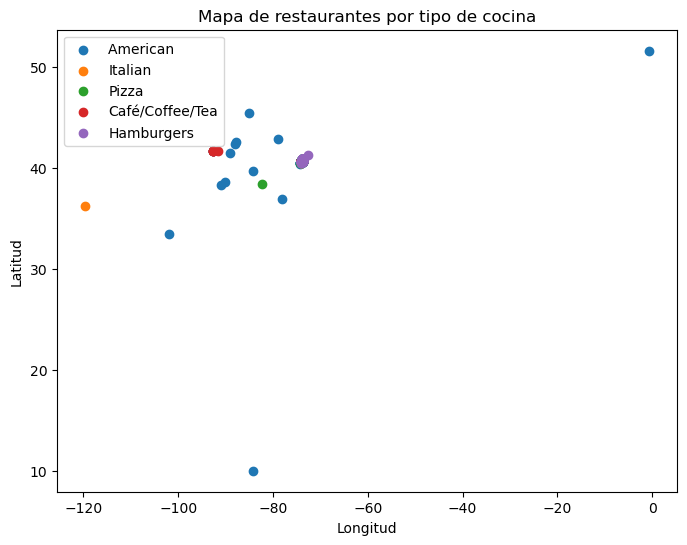

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Convertimos listas a arrays
lons_arr = np.array(lons)
lats_arr = np.array(lats)
cuisines_arr = np.array(cuisines)

# Nos quedamos solo con las 5 cocinas más frecuentes
from collections import Counter

top_cuisines = [c[0] for c in Counter(cuisines).most_common(5)]

plt.figure(figsize=(8,6))

for cuisine in top_cuisines:
    mask = cuisines_arr == cuisine
    plt.scatter(lons_arr[mask], lats_arr[mask], label=cuisine)

plt.title("Mapa de restaurantes por tipo de cocina")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.legend()
plt.show()


# Guardar mapa como archivo PNG

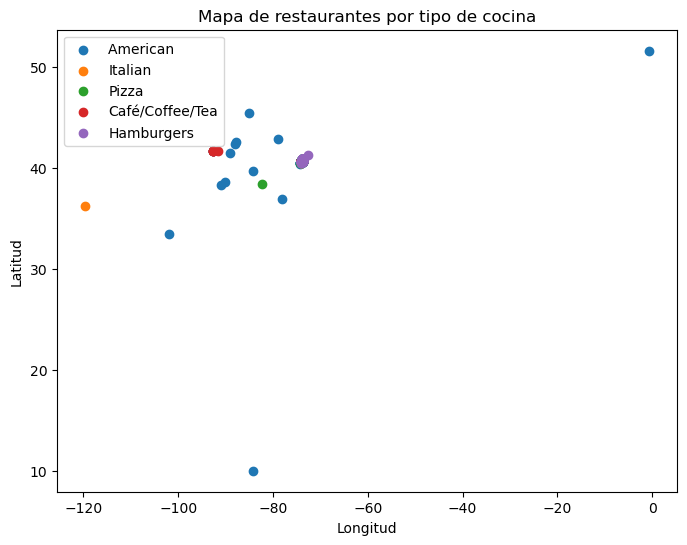

In [23]:
plt.figure(figsize=(8,6))

for cuisine in top_cuisines:
    mask = cuisines_arr == cuisine
    plt.scatter(lons_arr[mask], lats_arr[mask], label=cuisine)

plt.title("Mapa de restaurantes por tipo de cocina")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.legend()

plt.savefig("mapa_restaurantes.png")
plt.show()


# Conclusión
En esta práctica se ha trabajado con PyMongo para:

- Conectar con MongoDB desde Python.
- Realizar consultas básicas y avanzadas.
- Insertar nuevos documentos desde un archivo JSON.
- Crear un nuevo campo calculado (`avg_score`) en cada documento.
- Generar visualizaciones con matplotlib.
- Representar geográficamente los restaurantes según sus coordenadas.

Se ha combinado el uso de consultas MongoDB con procesamiento en Python,
demostrando la integración entre base de datos NoSQL y análisis de datos.